# CP1: Прогнозирование цены ноутбуков

Этот ноутбук собирает базовый аналитический pipeline для первого чекпоинта:

- загружает сырой датасет из `data/raw/laptops.csv` и при наличии сверяет его со `SQLite`-базой `laptops.db`;
- очищает и обогащает признаки через функции из `src.preprocessing`;
- проводит первичный EDA и визуализацию распределений;
- делит данные на train/validation/test с `SEED = 42`;
- сравнивает наивный baseline и Ridge-регрессию;
- сохраняет итоговую baseline-модель и метрики в папку `models`.

Основная метрика качества: **MAE**. Для задачи прогнозирования цены она наиболее интерпретируема, потому что напрямую измеряет среднюю ошибку в рублях без квадратичного штрафа за редкие выбросы. Дополнительно считаются `RMSE` и `R²`.

In [6]:
from __future__ import annotations

import json
import sqlite3
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.modeling import (
    BASE_FEATURE_COLUMNS,
    TARGET_COLUMN,
    build_baseline_pipeline,
    build_dummy_regressor,
    evaluate_regression,
    fit_and_score,
    save_model,
    split_dataset,
)
from src.preprocessing import clean_laptops_dataframe, load_raw_dataset
from src.project_config import SEED

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 100)

RAW_CSV = ROOT / "data" / "raw" / "laptops.csv"
RAW_DB = ROOT / "laptops.db"
PROCESSED_CSV = ROOT / "data" / "processed" / "laptops_clean.csv"
MODEL_PATH = ROOT / "models" / "baseline_ridge.joblib"
METRICS_PATH = ROOT / "models" / "baseline_metrics.json"
RAW_DATA_AVAILABLE = RAW_CSV.exists()

print(f"SEED = {SEED}")
print(f"RAW CSV: {RAW_CSV}")
print(f"RAW DB: {RAW_DB}")
print(f"RAW data available: {RAW_DATA_AVAILABLE}")

SEED = 42
RAW CSV: c:\VScodePROJECT\hseml-group-project-egorzubarev-2\data\raw\laptops.csv
RAW DB: c:\VScodePROJECT\hseml-group-project-egorzubarev-2\laptops.db
RAW data available: True


## Загрузка сырого датасета

На этом этапе ноутбук поднимает итоговый `CSV`, а если рядом уже лежит `SQLite`-база, дополнительно сверяет число строк в таблице `laptops`. Это удобная sanity-check проверка после скрейпа и дедупликации.

In [7]:
if not RAW_DATA_AVAILABLE:
    raise FileNotFoundError(
        "Не найден data/raw/laptops.csv. Сначала завершите скрейпинг и сбор финального raw-датасета."
    )

raw_df = load_raw_dataset(str(RAW_CSV))
print(f"raw shape: {raw_df.shape}")

if RAW_DB.exists():
    with sqlite3.connect(RAW_DB) as connection:
        db_rows = pd.read_sql_query("SELECT COUNT(*) AS row_count FROM laptops", connection)
    display(db_rows)

raw_df.head()

raw shape: (1636, 17)


,row_count
0,1636


,fingerprint,name,brand,price_rub,screen_diagonal_inch,screen_resolution,matrix_type,cpu,gpu,ram_gb,ram_type,storage_gb,os,weight_kg,sources,source_urls,raw_specs_json
0,14e5804f54becd1718900b7a0e7253e3d48695f02a4ffc...,"Ноутбук AZERTY Story RB-1451, 14"", IPS, Intel ...",Intel,20220,14.0,1920x1080,IPS,Intel Celeron N4020,Intel UHD Graphics,8,DDR4,128,Windows 11 Pro,NaN,[citilink],{'citilink': 'https://www.citilink.ru/product/...,{'citilink': {'Процессор': 'Intel Celeron N402...
1,02ce776a2fd68660e4e724954eb6f4755af2d22992983f...,"Ноутбук AZERTY Story RB-1451, 14"", IPS, Intel ...",Intel,21640,14.0,1920x1080,IPS,Intel Celeron N4020,Intel UHD Graphics,8,DDR4,256,Windows 11 Pro,NaN,[citilink],{'citilink': 'https://www.citilink.ru/product/...,{'citilink': {'Процессор': 'Intel Celeron N402...
2,e0d2025b381a3521ef79ef6d6616b453f9d4191e99b9a3...,"15.6"" Ноутбук DEXP Aquilon серый",Dexp,23999,15.6,1920x1080,IPS,Intel Celeron N4020C,Intel UHD Graphics,8,DDR4,256,Windows 11 Home,1.67,[dns],{'dns': 'https://www.dns-shop.ru/product/48b65...,"{'dns': {'Классификация / Тип': 'ноутбук', 'Кл..."
3,40217795602bcc65ad84b93c0af03f1b5fddc7170f76fe...,"14.1"" Ноутбук DEXP Aquilon серый",Dexp,24499,14.1,1920x1080,IPS,Intel Celeron N5095,Intel UHD Graphics,8,LPDDR4X,256,Windows 11 Pro,1.40,[dns],{'dns': 'https://www.dns-shop.ru/product/30d8e...,"{'dns': {'Классификация / Тип': 'ноутбук', 'Кл..."
4,e210f5919b892f7113395984cc44d6e9195d7c0c6d615e...,"Ноутбук AZERTY Story RB-1550, 15.6"", IPS, Inte...",15.6,26810,15.6,1920x1080,IPS,Intel Celeron N5095,Intel UHD Graphics,8,DDR4,256,Windows 11 Pro,NaN,[citilink],{'citilink': 'https://www.citilink.ru/product/...,"{'citilink': {'Экран': '15.6 ""; 1920х1080; IPS..."


## Очистка и feature engineering

Используем единый preprocessing-слой из `src/`, чтобы очистка в ноутбуке совпадала с кодом проекта: нормализуем типы, удаляем пустые таргеты, добавляем разложение разрешения, признаки вендоров CPU/GPU и несколько простых бинарных признаков.

In [8]:
df = clean_laptops_dataframe(raw_df)
PROCESSED_CSV.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(PROCESSED_CSV, index=False)

summary = pd.DataFrame(
    {
        "rows": [len(df)],
        "brands": [df["brand"].nunique()],
        "median_price_rub": [df["price_rub"].median()],
        "median_ram_gb": [df["ram_gb"].median()],
        "median_storage_gb": [df["storage_gb"].median()],
    }
)

display(summary)
df.head()

,rows,brands,median_price_rub,median_ram_gb,median_storage_gb
0,1565,39,92820.0,16.0,512.0


,fingerprint,name,brand,price_rub,screen_diagonal_inch,screen_resolution,matrix_type,cpu,gpu,ram_gb,ram_type,storage_gb,os,weight_kg,sources,source_urls,raw_specs_json,resolution_width,resolution_height,screen_pixels_mln,cpu_vendor,gpu_vendor,is_discrete_gpu,is_without_os,is_gaming_series
0,14e5804f54becd1718900b7a0e7253e3d48695f02a4ffc...,"Ноутбук AZERTY Story RB-1451, 14"", IPS, Intel ...",Intel,20220,14.0,1920x1080,IPS,Intel Celeron N4020,Intel UHD Graphics,8,DDR4,128,Windows 11 Pro,NaN,[citilink],{'citilink': 'https://www.citilink.ru/product/...,{'citilink': {'Процессор': 'Intel Celeron N402...,1920,1080,2.0736,Intel,Intel,0,0,0
1,02ce776a2fd68660e4e724954eb6f4755af2d22992983f...,"Ноутбук AZERTY Story RB-1451, 14"", IPS, Intel ...",Intel,21640,14.0,1920x1080,IPS,Intel Celeron N4020,Intel UHD Graphics,8,DDR4,256,Windows 11 Pro,NaN,[citilink],{'citilink': 'https://www.citilink.ru/product/...,{'citilink': {'Процессор': 'Intel Celeron N402...,1920,1080,2.0736,Intel,Intel,0,0,0
2,e0d2025b381a3521ef79ef6d6616b453f9d4191e99b9a3...,"15.6"" Ноутбук DEXP Aquilon серый",Dexp,23999,15.6,1920x1080,IPS,Intel Celeron N4020C,Intel UHD Graphics,8,DDR4,256,Windows 11 Home,1.67,[dns],{'dns': 'https://www.dns-shop.ru/product/48b65...,"{'dns': {'Классификация / Тип': 'ноутбук', 'Кл...",1920,1080,2.0736,Intel,Intel,0,0,0
3,40217795602bcc65ad84b93c0af03f1b5fddc7170f76fe...,"14.1"" Ноутбук DEXP Aquilon серый",Dexp,24499,14.1,1920x1080,IPS,Intel Celeron N5095,Intel UHD Graphics,8,LPDDR4X,256,Windows 11 Pro,1.40,[dns],{'dns': 'https://www.dns-shop.ru/product/30d8e...,"{'dns': {'Классификация / Тип': 'ноутбук', 'Кл...",1920,1080,2.0736,Intel,Intel,0,0,0
4,e210f5919b892f7113395984cc44d6e9195d7c0c6d615e...,"Ноутбук AZERTY Story RB-1550, 15.6"", IPS, Inte...",15.6,26810,15.6,1920x1080,IPS,Intel Celeron N5095,Intel UHD Graphics,8,DDR4,256,Windows 11 Pro,NaN,[citilink],{'citilink': 'https://www.citilink.ru/product/...,"{'citilink': {'Экран': '15.6 ""; 1920х1080; IPS...",1920,1080,2.0736,Intel,Intel,0,0,0


## EDA

Ниже базовый срез по распределению цен, брендам и аппаратным характеристикам. Для baseline-этапа этого достаточно, чтобы увидеть типичный диапазон цен и понять, какие признаки потенциально сильнее связаны с таргетом.

,count,median
brand,,
Asus,354,99999.0
Lenovo,195,104990.0
Msi,157,154999.0
Acer,125,77999.0
Apple,95,171999.0
Tecno,64,53399.0
Hp,61,94649.0
Maibenben,57,55999.0
Honor,54,69999.0


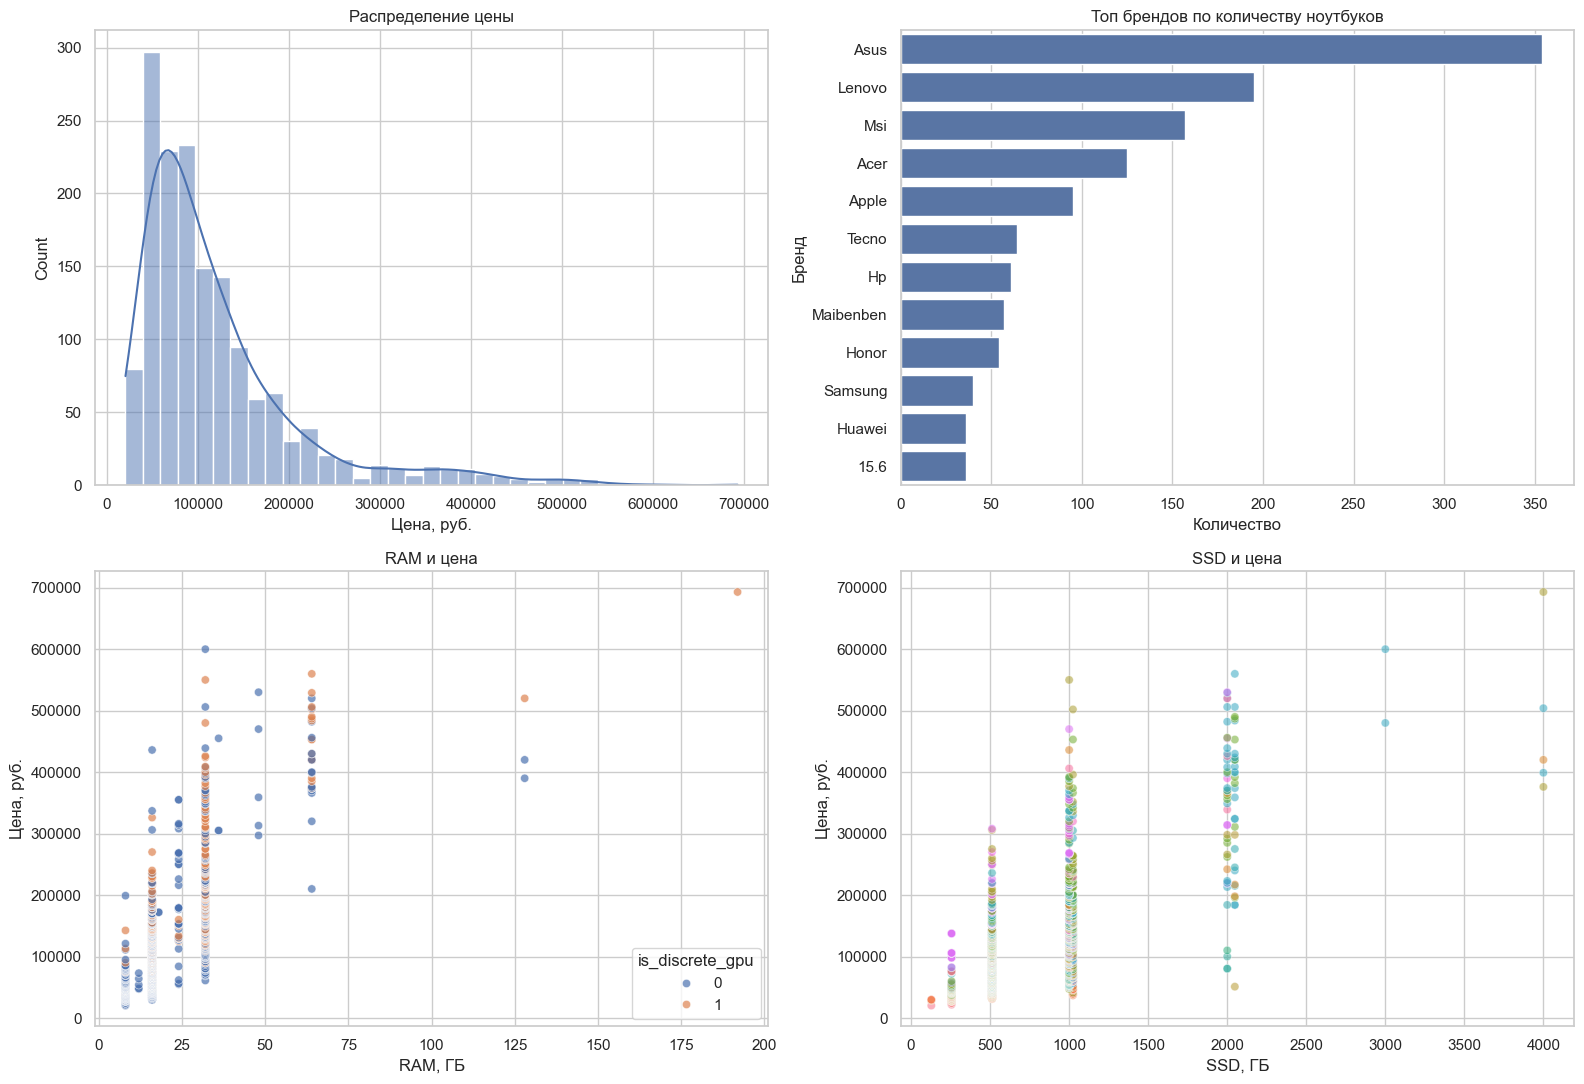

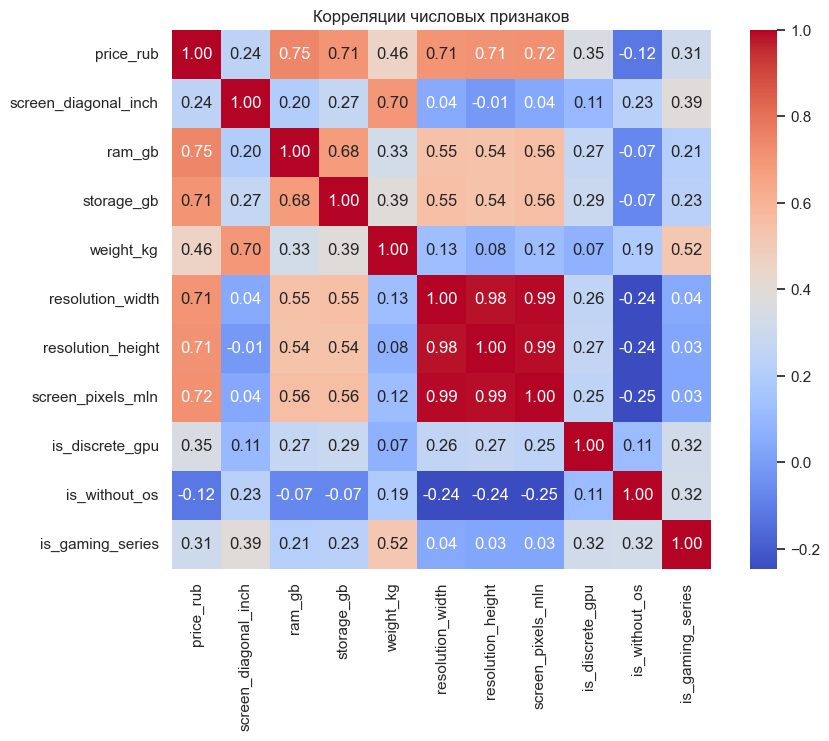

In [9]:
top_brands = (
    df.groupby("brand", dropna=False)["price_rub"]
    .agg(["count", "median"])
    .sort_values("count", ascending=False)
    .head(12)
)
display(top_brands)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.histplot(df["price_rub"], bins=35, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Распределение цены")
axes[0, 0].set_xlabel("Цена, руб.")

sns.barplot(
    data=top_brands.reset_index(),
    x="count",
    y="brand",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Топ брендов по количеству ноутбуков")
axes[0, 1].set_xlabel("Количество")
axes[0, 1].set_ylabel("Бренд")

sns.scatterplot(data=df, x="ram_gb", y="price_rub", hue="is_discrete_gpu", alpha=0.7, ax=axes[1, 0])
axes[1, 0].set_title("RAM и цена")
axes[1, 0].set_xlabel("RAM, ГБ")
axes[1, 0].set_ylabel("Цена, руб.")

sns.scatterplot(data=df, x="storage_gb", y="price_rub", hue="brand", legend=False, alpha=0.55, ax=axes[1, 1])
axes[1, 1].set_title("SSD и цена")
axes[1, 1].set_xlabel("SSD, ГБ")
axes[1, 1].set_ylabel("Цена, руб.")

plt.tight_layout()
plt.show()

corr_columns = [
    "price_rub",
    "screen_diagonal_inch",
    "ram_gb",
    "storage_gb",
    "weight_kg",
    "resolution_width",
    "resolution_height",
    "screen_pixels_mln",
    "is_discrete_gpu",
    "is_without_os",
    "is_gaming_series",
]

corr = df[corr_columns].corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Корреляции числовых признаков")
plt.show()

## Разбиение выборки и baseline

Данные делятся на train/validation/test в пропорции примерно `70/15/15` с фиксированным `SEED = 42`. Для sanity-check сначала обучается `DummyRegressor`, который всегда предсказывает медиану цены, а затем Ridge-регрессия с `OneHotEncoder` для категориальных признаков и стандартизацией числовых.

In [10]:
splits = split_dataset(df)
train_df = splits["train"]
validation_df = splits["validation"]
test_df = splits["test"]
feature_columns = [column for column in BASE_FEATURE_COLUMNS if column in df.columns]

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(train_df), len(validation_df), len(test_df)],
        "price_median": [
            train_df[TARGET_COLUMN].median(),
            validation_df[TARGET_COLUMN].median(),
            test_df[TARGET_COLUMN].median(),
        ],
    }
)
display(split_summary)

dummy = build_dummy_regressor()
dummy.fit(train_df[feature_columns], train_df[TARGET_COLUMN])
dummy_validation_predictions = dummy.predict(validation_df[feature_columns])
dummy_validation_metrics = evaluate_regression(validation_df[TARGET_COLUMN], dummy_validation_predictions)

ridge_validation = fit_and_score(build_baseline_pipeline(train_df), train_df, validation_df)

validation_metrics = pd.DataFrame(
    [
        {"model": "DummyRegressor", **dummy_validation_metrics},
        {"model": "Ridge", **ridge_validation["metrics"]},
    ]
).set_index("model")

validation_metrics

,split,rows,price_median
0,train,1095,89999.0
1,validation,235,96999.0
2,test,235,92999.0


,mae,rmse,r2
model,,,
DummyRegressor,64773.540426,106867.898940,-0.164853
Ridge,19766.503320,37929.330993,0.853267


In [11]:
train_val_df = pd.concat([train_df, validation_df], ignore_index=True)
final_model_result = fit_and_score(build_baseline_pipeline(train_val_df), train_val_df, test_df)
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
save_model(final_model_result["model"], MODEL_PATH)

final_metrics = {
    "seed": SEED,
    "validation": {
        "dummy": dummy_validation_metrics,
        "ridge": ridge_validation["metrics"],
    },
    "test": final_model_result["metrics"],
    "feature_columns": feature_columns,
}
METRICS_PATH.write_text(json.dumps(final_metrics, ensure_ascii=False, indent=2), encoding="utf-8")

pd.DataFrame(
    [
        {"stage": "validation", "model": "DummyRegressor", **dummy_validation_metrics},
        {"stage": "validation", "model": "Ridge", **ridge_validation["metrics"]},
        {"stage": "test", "model": "Ridge", **final_model_result["metrics"]},
    ]
)

,stage,model,mae,rmse,r2
0,validation,DummyRegressor,64773.540426,106867.898940,-0.164853
1,validation,Ridge,19766.503320,37929.330993,0.853267
2,test,Ridge,18659.708399,29576.911583,0.888457


## Простая линейная регрессия без feature engineering

Используем только исходные признаки датасета: числовые (`screen_diagonal_inch`, `ram_gb`, `storage_gb`, `weight_kg`) и категориальные (`brand`, `matrix_type`, `screen_resolution`, `cpu`, `gpu`, `ram_type`, `os`). Никаких производных колонок (`cpu_vendor`, `is_discrete_gpu` и т.д.) нет — только то, что есть в сыром CSV.

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# --- признаки из raw-датасета, без engineered-колонок ---
NUMERIC_RAW = ["screen_diagonal_inch", "ram_gb", "storage_gb", "weight_kg"]
CATEGORICAL_RAW = ["brand", "matrix_type", "screen_resolution", "cpu", "gpu", "ram_type", "os"]

raw_features = NUMERIC_RAW + CATEGORICAL_RAW

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, NUMERIC_RAW),
    ("cat", categorical_pipe, CATEGORICAL_RAW),
])

linreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

# --- обучение на train_df ---
linreg_pipeline.fit(train_df[raw_features], train_df[TARGET_COLUMN])

# --- оценка на validation ---
val_pred = linreg_pipeline.predict(validation_df[raw_features])
linreg_val_metrics = evaluate_regression(validation_df[TARGET_COLUMN], val_pred)

# --- итоговая проверка на test (модель переобучается на train+val) ---
linreg_final = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", numeric_pipe, NUMERIC_RAW),
        ("cat", categorical_pipe, CATEGORICAL_RAW),
    ])),
    ("model", LinearRegression()),
])
linreg_final.fit(train_val_df[raw_features], train_val_df[TARGET_COLUMN])
test_pred = linreg_final.predict(test_df[raw_features])
linreg_test_metrics = evaluate_regression(test_df[TARGET_COLUMN], test_pred)

comparison = pd.DataFrame([
    {"model": "DummyRegressor (median)", "stage": "validation", **dummy_validation_metrics},
    {"model": "Ridge (all features)",    "stage": "validation", **ridge_validation["metrics"]},
    {"model": "LinearRegression (raw)",  "stage": "validation", **linreg_val_metrics},
    {"model": "Ridge (all features)",    "stage": "test",       **final_model_result["metrics"]},
    {"model": "LinearRegression (raw)",  "stage": "test",       **linreg_test_metrics},
])
comparison = comparison.set_index(["model", "stage"])
display(comparison)


,,mae,rmse,r2
model,stage,,,
DummyRegressor (median),validation,64773.540426,106867.898940,-0.164853
Ridge (all features),validation,19766.503320,37929.330993,0.853267
LinearRegression (raw),validation,21922.633571,40229.238784,0.834933
Ridge (all features),test,18659.708399,29576.911583,0.888457
LinearRegression (raw),test,19206.724363,29390.386407,0.889859


## Вывод

Если Ridge уверенно лучше `DummyRegressor` по `MAE`, то baseline для CP1 можно считать собранным: данные очищены, признаки формализованы, метрики зафиксированы, а модель сохранена в `models/baseline_ridge.joblib`. 
